In [43]:
import numpy as np 
import matplotlib.pyplot as plt

A = 1 
alpha = 0.1 
gamma = 0.5
epsilon = 0.01
iapp = 0.5 
v0 = 0.0
w0 = 0.5
d = 0.01 #difusao


h=0.0001 #passos de tempo
delta_x = 0.01 #passo espacial

xf = 1.0
tf = 5 #tempo final

t = np.arange(0, tf + h, h)
x = np.arange(0, xf + delta_x, delta_x)


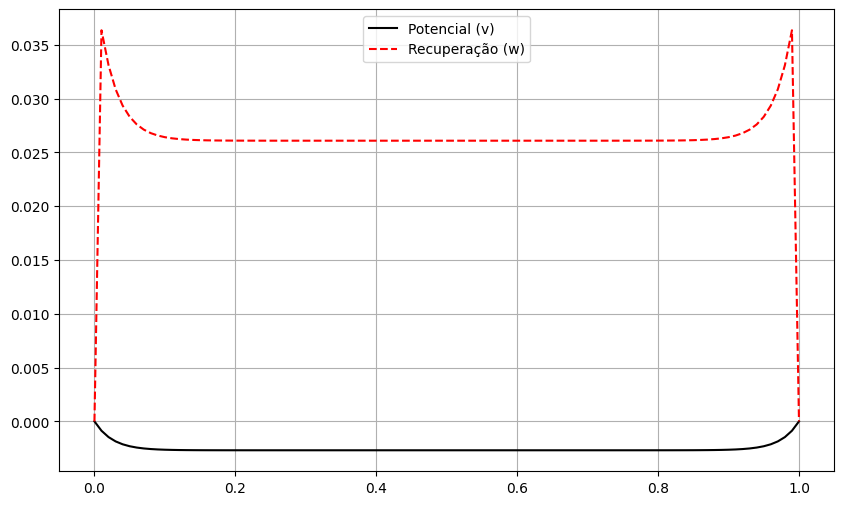

In [44]:
def I_ion(v,w):
    return (1/epsilon)*(A*v*(alpha - v)*(v - 1)) - w - w0 + iapp

def g(v,w):
    return v - gamma*w


V = np.zeros((len(t), len(x))) 
W = np.zeros((len(t), len(x)))
#condicoes de contorno
V[0, :] = v0
W[0, :] = w0

for i in range(len(t)-1):
    for j in range(1, len(x)-1):
        dvdt = d*(V[i,j+1] - 2*V[i,j] +V[i,j-1])/delta_x**2 + I_ion(V[i,j], W[i,j])
        dwdt = g(V[i,j], W[i,j])

        V[i+1,j] = V[i,j] + dvdt * h
        W[i+1,j] = W[i,j] + dwdt * h







plt.figure(figsize=(10, 6))
plt.plot(x, V[-1,:], label='Potencial (v)', color='black')
plt.plot(x, W[-1,:], label='Recuperação (w)', color='red', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()